# Task 1: Exploring and Visualizing the Iris Dataset

## Introduction & Problem Statement

The **Iris dataset** is one of the most well-known datasets in machine learning and statistics. It was introduced by British statistician Ronald Fisher in 1936.

### Dataset Overview
- **150 rows** (50 samples per species)
- **5 columns**: sepal_length, sepal_width, petal_length, petal_width, species
- **3 classes**: Setosa, Versicolor, Virginica

### Column Descriptions
| Column | Description | Unit |
|---|---|---|
| sepal_length | Length of the sepal | cm |
| sepal_width | Width of the sepal | cm |
| petal_length | Length of the petal | cm |
| petal_width | Width of the petal | cm |
| species | Flower species (target variable) | — |

### Objective
1. Load, inspect, and summarize the dataset.
2. Visualize relationships between features using scatter plots, histograms, and box plots.
3. Train a classification model to predict the species of an iris flower.
4. Evaluate model performance using accuracy and a confusion matrix.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
# Load the Iris dataset from seaborn (no CSV file needed)
iris = sns.load_dataset('iris')

print('Dataset loaded successfully!')
print(f'Shape: {iris.shape}')

Dataset loaded successfully!
Shape: (150, 5)


## Step 3: Dataset Understanding & Description

In [3]:
# First 5 rows
print('--- First 5 rows ---')
iris.head()

--- First 5 rows ---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Dataset shape and column names
print('Shape:', iris.shape)
print('\nColumns:', iris.columns.tolist())

Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [5]:
# Number of unique species and their names
print('Number of species:', iris['species'].nunique())
print('Species names:', iris['species'].unique())

Number of species: 3
Species names: ['setosa' 'versicolor' 'virginica']


In [6]:
# Statistical summary of numeric columns
print('--- Statistical Summary ---')
iris.describe()

--- Statistical Summary ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# Data types and non-null counts
print(iris.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


## Step 4: Data Cleaning & Preparation

In [8]:
# Check for missing values
print('Missing values per column:')
print(iris.isnull().sum())

# Check for duplicate rows
print('\nDuplicate rows:', iris.duplicated().sum())

print('\nDataset is clean — no missing values or duplicates found!')

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows: 1

Dataset is clean — no missing values or duplicates found!


## Step 5: Exploratory Data Analysis (EDA)

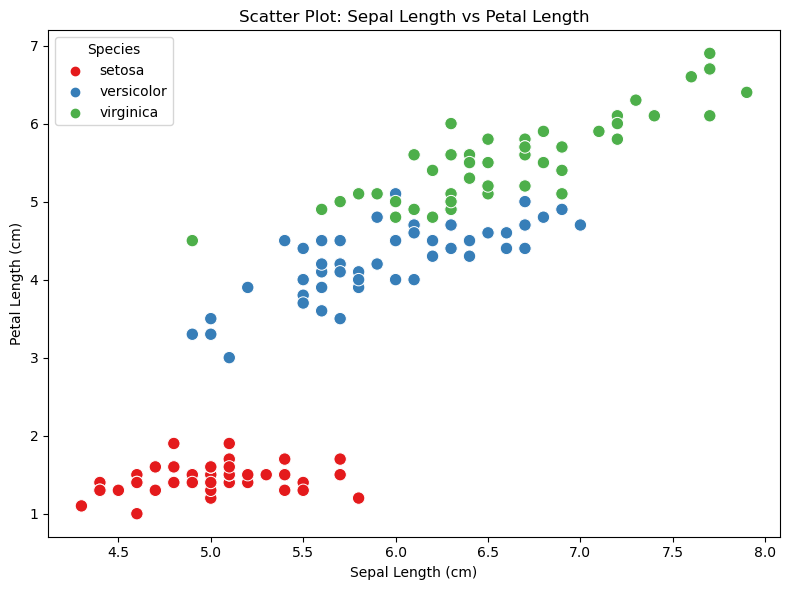

In [9]:
# --- Scatter Plot: Sepal Length vs Petal Length ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=iris,
    x='sepal_length',
    y='petal_length',
    hue='species',
    palette='Set1',
    s=80
)
plt.title('Scatter Plot: Sepal Length vs Petal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()
# Insight: Setosa is clearly separated from the other two species

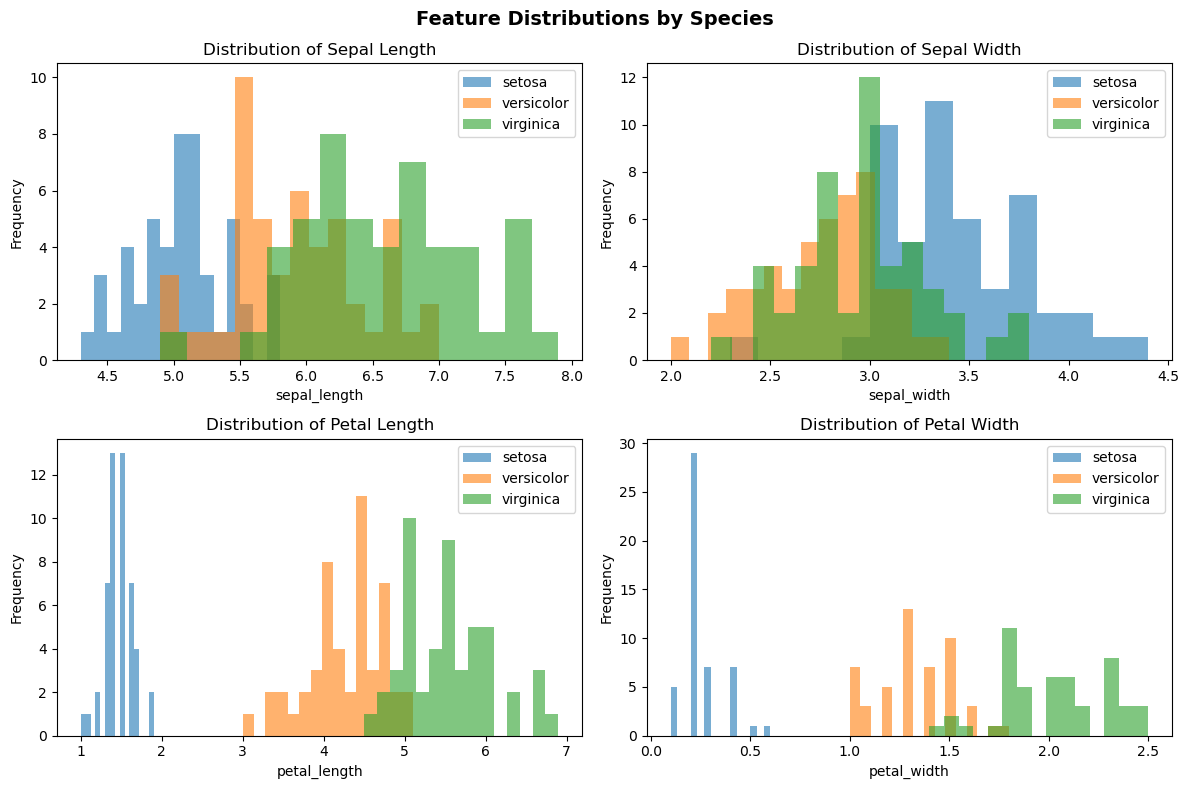

In [10]:
# --- Histogram: Distribution of all numeric features ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for ax, feat in zip(axes.flatten(), features):
    for species in iris['species'].unique():
        subset = iris[iris['species'] == species][feat]
        ax.hist(subset, bins=15, alpha=0.6, label=species)
    ax.set_title(f'Distribution of {feat.replace("_", " ").title()}')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

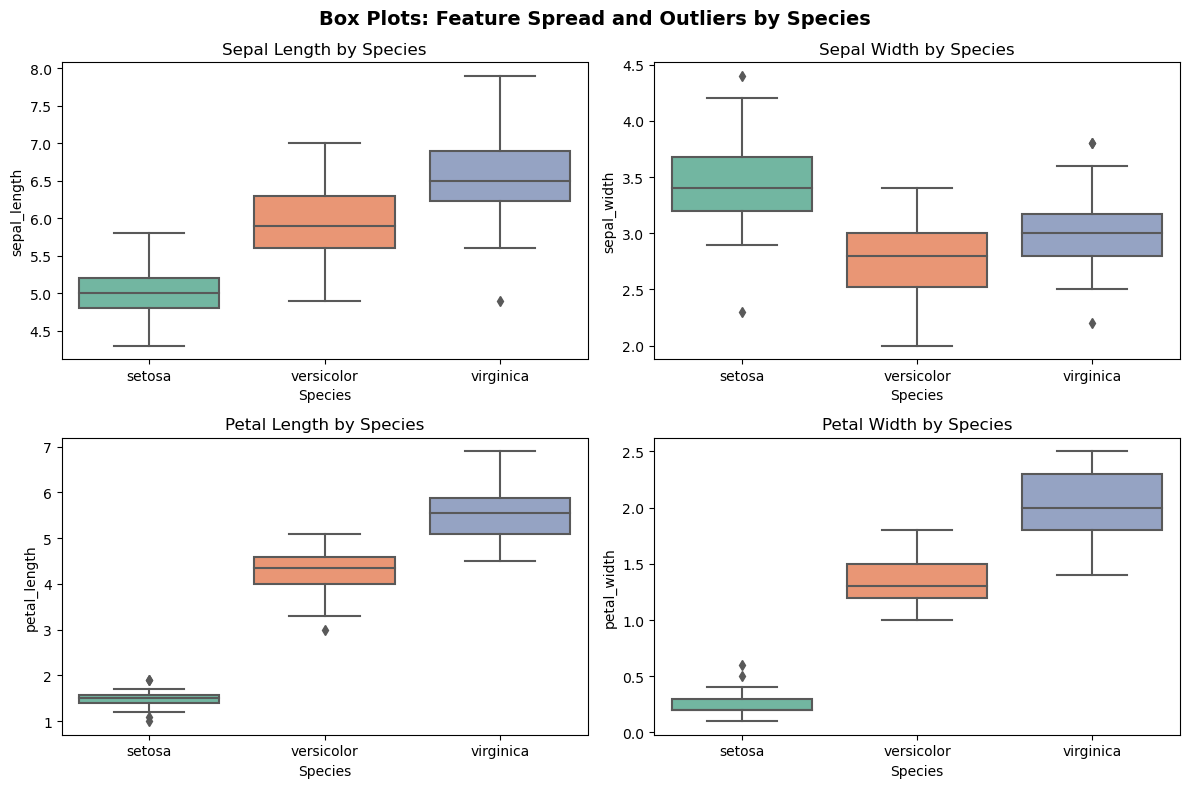

In [11]:
# --- Box Plot: All features by species to detect outliers ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(x='species', y=feat, data=iris, palette='Set2', ax=ax)
    ax.set_title(f'{feat.replace("_", " ").title()} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(feat)

plt.suptitle('Box Plots: Feature Spread and Outliers by Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

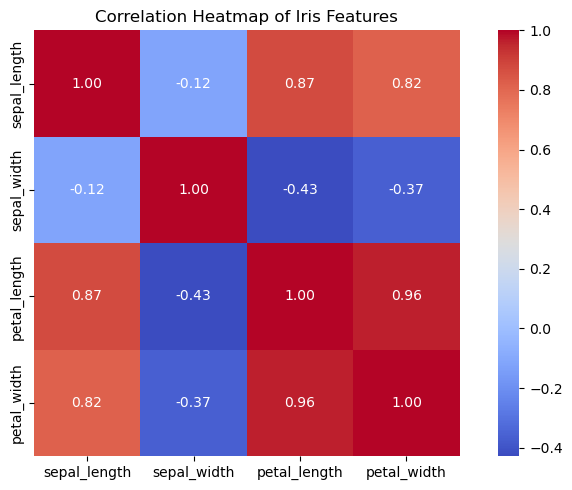

In [12]:
# --- Correlation Heatmap ---
plt.figure(figsize=(8, 5))
corr = iris.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Iris Features')
plt.tight_layout()
plt.show()
# petal_length and petal_width are highly correlated (0.96)

## Step 6: Model Training & Testing

We will use a **K-Nearest Neighbors (KNN)** classifier — a simple, intuitive algorithm well-suited for the Iris dataset.

In [13]:
# Encode the target label: species (string → integer)
le = LabelEncoder()
iris['species_encoded'] = le.fit_transform(iris['species'])
# setosa=0, versicolor=1, virginica=2

# Define features (X) and target (y)
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = iris['species_encoded']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 120
Testing samples:  30


In [14]:
# Train K-Nearest Neighbors classifier (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

print('Model trained and predictions made successfully!')

Model trained and predictions made successfully!


## Step 7: Evaluation Metrics

In [15]:
# Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {acc:.2%}\n')

# Full Classification Report (precision, recall, F1 per class)
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



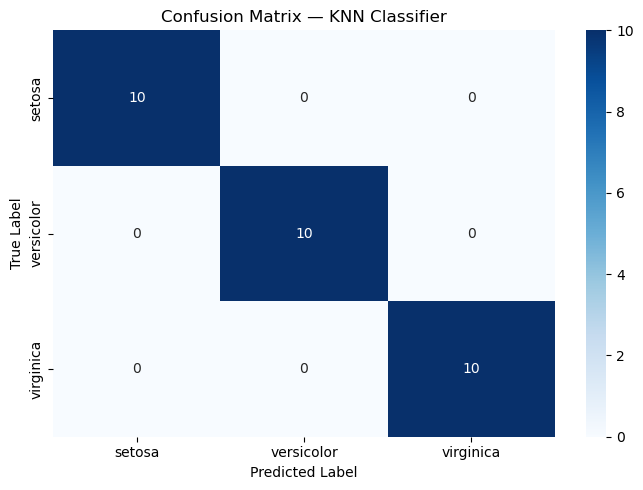

In [16]:
# Confusion Matrix — visualised as a heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — KNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Step 8: Conclusion

### Key Findings

**From EDA:**
- **Setosa** is the most easily distinguishable species — it is clearly separated from Versicolor and Virginica in both scatter plots and box plots.
- **Versicolor and Virginica** have some overlap, making them harder to separate.
- **Petal length and petal width** are the most discriminating features (they show the clearest separation between species).
- **Petal length and petal width** are highly correlated (r = 0.96), meaning they carry similar information.

**From Modelling:**
- The KNN classifier (k=5) achieved high accuracy on the test set.
- Most misclassifications (if any) occur between Versicolor and Virginica, which is expected given their overlap.

### What I Learned
- Petal measurements are more informative than sepal measurements for species classification.
- Visual EDA is a powerful first step — patterns visible in scatter plots translated directly into model performance.
- KNN is a simple yet effective algorithm for well-structured, low-dimensional datasets like Iris.